In [1]:
%pip install tensorflow opencv-python matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import tensorflow as tf
import numpy as np
import os
import cv2
from matplotlib import pyplot as plt

In [3]:
train_data = tf.keras.utils.image_dataset_from_directory('brain_mri_dataset/Training')

Found 5600 files belonging to 4 classes.


In [4]:
from collections import Counter

labels = []
for _, y in train_data.unbatch():
    labels.append(y.numpy())

counts = Counter(labels)
for i, name in enumerate(train_data.class_names):
    print(f"{name}: {counts[i]}")

glioma: 1400
meningioma: 1400
notumor: 1400
pituitary: 1400


In [5]:
data_iterator = train_data.as_numpy_iterator()

In [6]:
batch = data_iterator.next()

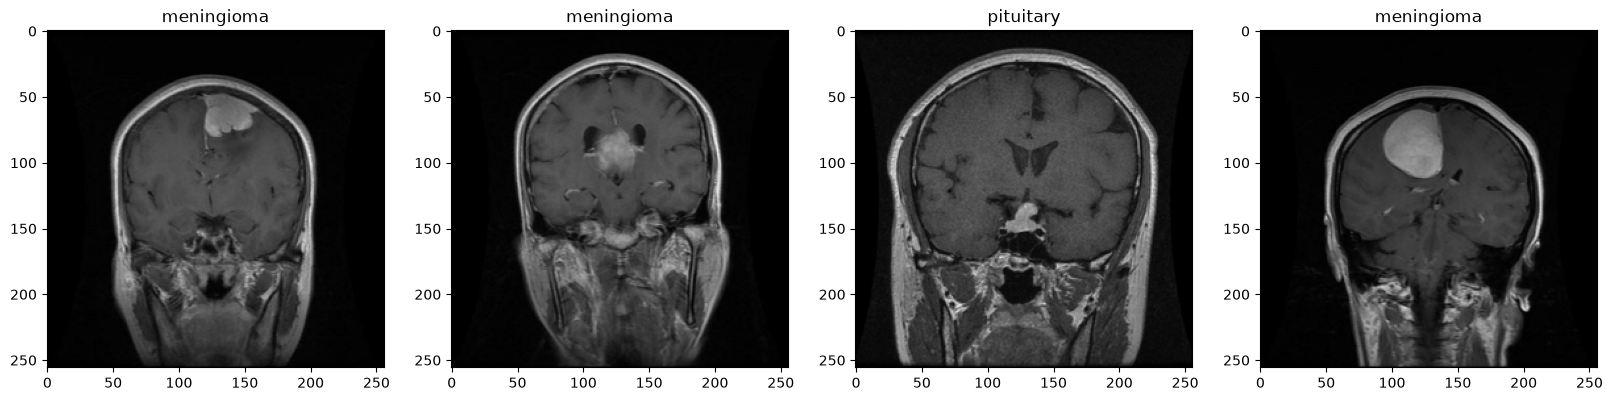

In [7]:
class_names = train_data.class_names
fig, ax = plt.subplots(ncols = 4, figsize = (20,20))
for idx, img in enumerate(batch[0][:4]):
    ax[idx].imshow(img.astype(int))
    ax[idx].title.set_text(class_names[batch[1][idx]])

In [8]:
train_data = train_data.map(lambda x,y: (x/255, y))

In [9]:
scaled = train_data.as_numpy_iterator().next()

In [10]:
scaled[0].max()

np.float32(1.0)

In [11]:
tf.random.set_seed(42)

train_data = train_data.shuffle(buffer_size=len(train_data), seed=42, reshuffle_each_iteration=False)

train_size = int(len(train_data) * 0.8)
val_size = len(train_data) - train_size
train = train_data.take(train_size)
val = train_data.skip(train_size)

In [12]:
test_data = tf.keras.utils.image_dataset_from_directory('brain_mri_dataset/Testing')
test_data = test_data.map(lambda x, y: (x/255, y))

Found 1600 files belonging to 4 classes.


In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout

In [14]:
model = Sequential()

model.add(Conv2D(16, (3,3), 1, activation ='relu', input_shape = (256,256,3)))
model.add(MaxPooling2D())

model.add(Conv2D(32, (3,3), 1, activation ='relu'))
model.add(MaxPooling2D())
model.add(Dropout(0.25))

model.add(Conv2D(64, (3,3), 1, activation ='relu'))
model.add(MaxPooling2D())
model.add(Dropout(0.25))

model.add(Conv2D(128, (3,3), 1, activation ='relu'))
model.add(MaxPooling2D())
model.add(Dropout(0.25))

model.add(Flatten())

model.add(Dense(256, activation ='relu'))
model.add(Dropout(0.5))
model.add(Dense(4, activation ='softmax'))

C:\Users\miken\OneDrive\Desktop\brain-tumor-detection\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
model.compile('adam', loss = tf.losses.SparseCategoricalCrossentropy(), metrics = ['accuracy'])

In [16]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 254, 254, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 127, 127, 16)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 125, 125, 32)        │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 62, 62, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 62, 62, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 60, 60, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │       6,422,784 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4)                   │           1,028 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,521,252 (24.88 MB)

 Trainable params: 6,521,252 (24.88 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint('best_model.keras', monitor='val_loss', save_best_only=True)

In [18]:
hist = model.fit(train, epochs = 20, validation_data = val, callbacks=[early_stop, checkpoint])

Epoch 1/20


C:\Users\miken\OneDrive\Desktop\brain-tumor-detection\venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


140/140 ━━━━━━━━━━━━━━━━━━━━ 53s 350ms/step - accuracy: 0.5904 - loss: 0.9822 - val_accuracy: 0.7598 - val_loss: 0.6037
Epoch 2/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 71s 487ms/step - accuracy: 0.7812 - loss: 0.5679 - val_accuracy: 0.8232 - val_loss: 0.4633
Epoch 3/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 71s 481ms/step - accuracy: 0.8257 - loss: 0.4615 - val_accuracy: 0.8616 - val_loss: 0.3584
Epoch 4/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 70s 479ms/step - accuracy: 0.8473 - loss: 0.4051 - val_accuracy: 0.8920 - val_loss: 0.2969
Epoch 5/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 71s 482ms/step - accuracy: 0.8730 - loss: 0.3315 - val_accuracy: 0.9116 - val_loss: 0.2501
Epoch 6/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 74s 509ms/step - accuracy: 0.8933 - loss: 0.2775 - val_accuracy: 0.8920 - val_loss: 0.2664
Epoch 7/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 73s 494ms/step - accuracy: 0.9123 - loss: 0.2402 - val_accuracy: 0.9464 - val_loss: 0.1617
Epoch 8/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 72s 488ms/step - accuracy: 0.9217 - loss: 0.2152 - val

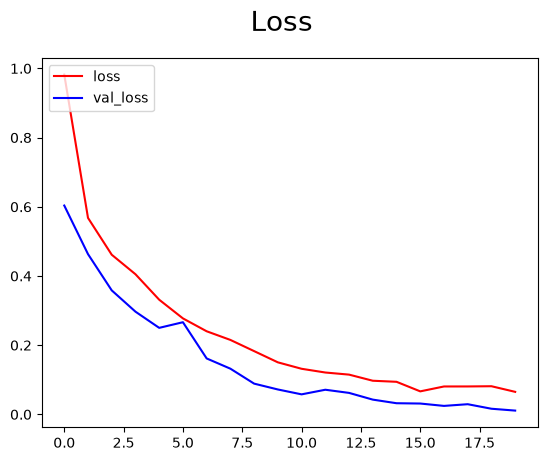

In [19]:
fig = plt.figure()
plt.plot(hist.history['loss'], color = 'red', label = 'loss')
plt.plot(hist.history['val_loss'], color = 'blue', label = 'val_loss')
fig.suptitle('Loss', fontsize = 20)
plt.legend(loc = "upper left")
plt.show()


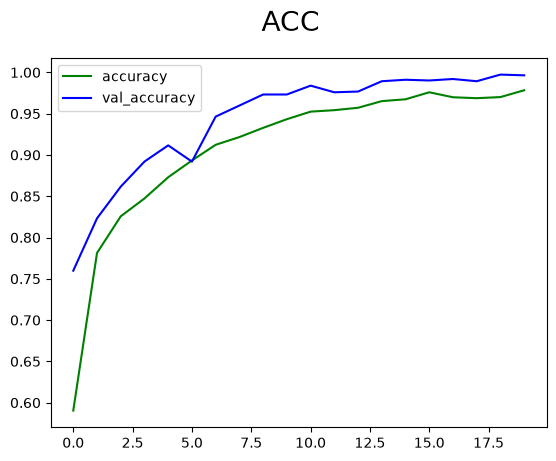

In [20]:
fig = plt.figure()
plt.plot(hist.history['accuracy'], color = 'green', label = 'accuracy')
plt.plot(hist.history['val_accuracy'], color = 'blue', label = 'val_accuracy')
fig.suptitle('ACC', fontsize = 20)
plt.legend(loc = "upper left")
plt.show()

In [21]:
model.evaluate(test_data)

50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 70ms/step - accuracy: 0.9031 - loss: 0.9352


[0.9351662993431091, 0.903124988079071]

In [22]:
%pip install scikit-learn seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


              precision    recall  f1-score   support

      glioma       0.94      0.73      0.82       400
  meningioma       0.85      0.92      0.88       400
     notumor       0.87      1.00      0.93       400
   pituitary       0.97      0.97      0.97       400

    accuracy                           0.90      1600
   macro avg       0.91      0.90      0.90      1600
weighted avg       0.91      0.90      0.90      1600



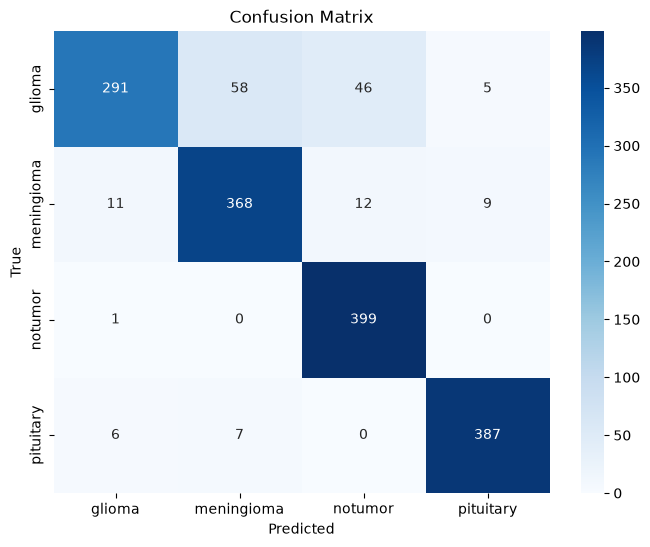

In [23]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

y_true = []
y_pred = []
for x, y in test_data:
    preds = model.predict(x, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(y.numpy())

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [24]:
model.save('CNNTest_v2.0.keras')